# IFU Baseline: Image Patch to Halpha

This notebook implements a simple baseline for Halpha map prediction from DESI images:
- Baseline: local DESI image patch directly to Halpha via linear ridge regression
- Model path: local coordinate to model spectrum to fitted Halpha

Both are evaluated on the same MaNGA spaxels for the same target galaxy.

In [1]:
import os
import sys
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import torch
import zarr
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

from scipy.optimize import curve_fit

sys.path.append('..')
from torch.utils.data import DataLoader
from utils.DataProcessing import MultimodalDataset
from utils.AstroImageFunctions import make_rgb
from models.MAESimple import MaskedAutoencoderViT

np.random.seed(0)
torch.manual_seed(0)
print('Imports loaded')

/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded


In [2]:
class PairExtractor:
    def __init__(
        self,
        desi_zarr_path='/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr',
        desi_parquet_path='/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet',
        drpall_cache='/pscratch/sd/p/pzehao/MyQuota/drpall-v3_1_1.fits',
        maps_cache_dir='/pscratch/sd/p/pzehao/MyQuota/manga_maps',
        cube_cache_dir='/pscratch/sd/p/pzehao/MyQuota/manga_cubes',
        map_daptype='HYB10-MILESHC-MASTARHC2',
    ):
        self.desi_zarr_path = Path(desi_zarr_path)
        self.desi_parquet_path = Path(desi_parquet_path)
        self.drpall_cache = Path(drpall_cache)
        self.maps_cache_dir = Path(maps_cache_dir)
        self.cube_cache_dir = Path(cube_cache_dir)
        self.map_daptype = map_daptype

        self.z = zarr.open(str(self.desi_zarr_path), mode='r')
        self.wave = np.asarray(self.z['WAVE'][:], dtype=np.float32)
        self._desi = None
        self._manga = None

    @staticmethod
    def _txt(x):
        if isinstance(x, (bytes, np.bytes_)):
            return x.decode('utf-8')
        return str(x)

    def desi_table(self):
        if self._desi is None:
            cols = ['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'MEAN_FIBER_RA', 'MEAN_FIBER_DEC', 'Z']
            t = pd.read_parquet(self.desi_parquet_path, columns=cols).copy()
            t['TARGETID'] = t['TARGETID'].astype(np.int64)
            self._desi = t
        return self._desi

    def manga_table(self):
        if self._manga is None:
            if not self.drpall_cache.exists():
                self.drpall_cache.parent.mkdir(parents=True, exist_ok=True)
                url = 'https://data.sdss.org/sas/dr17/manga/spectro/redux/v3_1_1/drpall-v3_1_1.fits'
                urlretrieve(url, self.drpall_cache)
            tbl = Table.read(self.drpall_cache, hdu=1)
            one_d = [c for c in tbl.colnames if len(tbl[c].shape) <= 1]
            df = tbl[one_d].to_pandas()
            df = df[['plateifu', 'objra', 'objdec']].copy()
            df['plateifu'] = df['plateifu'].map(self._txt)
            df = df.rename(columns={'objra': 'manga_ra', 'objdec': 'manga_dec'})
            self._manga = df
        return self._manga

    def get_loader(self, desi_index):
        ds = MultimodalDataset(str(self.desi_zarr_path), start=int(desi_index), end=int(desi_index) + 1, augment=False, max_shift=0)
        return DataLoader(ds, batch_size=1, shuffle=False)

    def match_manga(self, target_ra, target_dec):
        mt = self.manga_table()
        c1 = SkyCoord([target_ra] * u.deg, [target_dec] * u.deg)
        c2 = SkyCoord(mt['manga_ra'].to_numpy() * u.deg, mt['manga_dec'].to_numpy() * u.deg)
        idx, sep2d, _ = c1.match_to_catalog_sky(c2)
        return mt.iloc[int(idx[0])]['plateifu'], float(sep2d.arcsec[0])

    def _maps_path(self, plateifu):
        plate, ifu = plateifu.split('-')
        self.maps_cache_dir.mkdir(parents=True, exist_ok=True)
        p = self.maps_cache_dir / f'manga-{plateifu}-MAPS-{self.map_daptype}.fits.gz'
        if not p.exists():
            u = (
                f'https://data.sdss.org/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/'
                f'{self.map_daptype}/{plate}/{ifu}/manga-{plateifu}-MAPS-{self.map_daptype}.fits.gz'
            )
            urlretrieve(u, p)
        return p

    @staticmethod
    def _ch(header, token):
        token = token.lower()
        for k, v in header.items():
            if isinstance(k, str) and k.startswith('C') and isinstance(v, str) and token in v.lower():
                return int(k[1:]) - 1
        raise KeyError(token)

    @staticmethod
    def _masked(h, ext, idx=None):
        d = np.asarray(h[ext].data if idx is None else h[ext].data[idx], dtype=np.float32)
        bad = np.zeros_like(d, dtype=bool)
        me = f'{ext}_MASK'
        ie = f'{ext}_IVAR'
        if me in h:
            m = np.asarray(h[me].data if idx is None else h[me].data[idx])
            bad |= (m != 0)
        if ie in h:
            iv = np.asarray(h[ie].data if idx is None else h[ie].data[idx], dtype=np.float32)
            bad |= (~np.isfinite(iv)) | (iv <= 0)
        d[bad] = np.nan
        return d

    def get_maps(self, plateifu):
        p = self._maps_path(plateifu)
        with fits.open(p) as h:
            i_ha = self._ch(h['EMLINE_GFLUX'].header, 'Ha-6564')
            return {
                'manga_image': self._masked(h, 'SPX_MFLUX'),
                'ha_flux': self._masked(h, 'EMLINE_GFLUX', i_ha),
            }

extractor = PairExtractor()
desi_tab = extractor.desi_table()
matches_df = pd.read_csv('/pscratch/sd/p/pzehao/desi_manga_matches.csv')
matches_df = matches_df[matches_df['TARGETID'].isin(set(desi_tab['TARGETID'].values))].reset_index(drop=True)
print(f'Loaded {len(matches_df)} eligible cross-matches')

Loaded 521 eligible cross-matches


In [3]:
# --- Halpha extraction from predicted spectra (same spirit as your Cell 12) ---
C_KMS = 299792.458
HA_REST = 6564.61
NII6548_REST = 6549.86
NII6583_REST = 6585.27
NII_RATIO_6583_TO_6548 = 3.06

def _gauss_from_flux(lam, flux_int, mu, sigma):
    amp = flux_int / (np.sqrt(2.0 * np.pi) * sigma)
    return amp * np.exp(-0.5 * ((lam - mu) / sigma) ** 2)

def _halpha_single_dap_like(wave_obs, flux_obs, z_obj):
    wave_obs = np.asarray(wave_obs, dtype=np.float64)
    flux_obs = np.asarray(flux_obs, dtype=np.float64)

    lam0 = HA_REST * (1.0 + z_obj)
    win_half = 45.0 * (1.0 + z_obj)
    m = (
        np.isfinite(wave_obs)
        & np.isfinite(flux_obs)
        & (wave_obs >= lam0 - win_half)
        & (wave_obs <= lam0 + win_half)
    )

    w = wave_obs[m]
    f = flux_obs[m]
    if len(w) < 30:
        return np.nan

    side = ((w < lam0 - 12.0) | (w > lam0 + 12.0))
    c0 = float(np.nanmedian(f[side])) if np.any(side) else float(np.nanmedian(f))
    c1 = 0.0

    cont_guess = c0 + c1 * (w - lam0)
    pos = np.clip(f - cont_guess, 0.0, None)
    f_ha0 = max(float(np.trapz(pos, w)), 1e-3)
    f_nii6583_0 = 0.3 * f_ha0

    def model(lam, cont0, cont1, f_ha, f_nii6583, dv_kms, sigma_kms):
        z_shift = (1.0 + z_obj) * (1.0 + dv_kms / C_KMS)
        mu_ha = HA_REST * z_shift
        mu_6548 = NII6548_REST * z_shift
        mu_6583 = NII6583_REST * z_shift

        sigma_ha = (sigma_kms / C_KMS) * mu_ha
        sigma_6548 = (sigma_kms / C_KMS) * mu_6548
        sigma_6583 = (sigma_kms / C_KMS) * mu_6583

        f_nii6548 = f_nii6583 / NII_RATIO_6583_TO_6548
        y = cont0 + cont1 * (lam - lam0)
        y += _gauss_from_flux(lam, f_ha, mu_ha, sigma_ha)
        y += _gauss_from_flux(lam, f_nii6548, mu_6548, sigma_6548)
        y += _gauss_from_flux(lam, f_nii6583, mu_6583, sigma_6583)
        return y

    p0 = [c0, c1, f_ha0, f_nii6583_0, 0.0, 120.0]
    lower = [-np.inf, -np.inf, 0.0, 0.0, -400.0, 20.0]
    upper = [np.inf, np.inf, np.inf, np.inf, 400.0, 500.0]

    try:
        popt, _ = curve_fit(model, w, f, p0=p0, bounds=(lower, upper), maxfev=20000)
        return float(popt[2])
    except Exception:
        return np.nan

def extract_halpha_flux_batch(spectra, wave_obs, redshifts, left_patches=None, patch_size=None):
    wave_obs = np.asarray(wave_obs, dtype=np.float64)
    L = len(wave_obs)

    arr = np.asarray(spectra)
    if arr.ndim == 1:
        arr = arr[None, :]

    if arr.shape[1] != L:
        if left_patches is None or patch_size is None:
            raise ValueError('Need left_patches and patch_size for center extraction')
        o = int(left_patches) * int(patch_size)
        arr = arr[:, o:o + L]

    z_arr = np.asarray(redshifts, dtype=np.float64).reshape(-1)
    if len(z_arr) == 1:
        z_arr = np.full(arr.shape[0], z_arr[0], dtype=np.float64)

    out = np.full(arr.shape[0], np.nan, dtype=np.float64)
    for i in range(arr.shape[0]):
        out[i] = _halpha_single_dap_like(wave_obs, arr[i], z_arr[i])
    return out

print('Halpha helpers ready')

Halpha helpers ready


In [4]:
# --- Config ---
row_idx_target = 2
n_train_galaxies = 80
patch_radius = 3
ridge_alpha = 1.0
chunk_size_model = 64

# Model checkpoint used for comparison
ckpt_path = '/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=106-val_loss=-1.5629.ckpt'

# Model architecture (same as your notebook)
prob = 0.7 / 15

def build_model_and_load(path):
    m = MaskedAutoencoderViT(
        spec_dim=7781,
        max_epochs=600,
        warmup_epoch=5,
        mask_ratio=0.75,
        embed_dim=256,
        merged_depth=4,
        merged_num_heads=8,
        s_depth=4,
        e_depth=4,
        s_num_heads=8,
        e_num_heads=8,
        decoder_embed_dim=512,
        decoder_depth=8,
        decoder_num_heads=16,
        decoder_MLP_coefficient=1,
        patch_scheme={
            'patch_sizes': [1, 1, 2, 4, 8, 16, 32, 64, 128, 64, 32, 16, 8, 4, 2, 1],
            'mask_ratios': [1, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.2, 0.1, 0.0],
            'probs': [0.3, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob, prob],
        },
    )
    chk = torch.load(path, map_location='cpu')
    m.load_state_dict(chk['state_dict'], strict=False)
    m.mask_ratio = 1.0
    m.mask_ratio_img = 0.0
    m.eval()
    return m

def xy_to_img_pixel(dx, dy, w=128, h=128):
    x = dx + (w / 2.0)
    y = (h / 2.0) - dy
    return x, y

def extract_patch_features(img_6ch, x_off, y_off, radius=3):
    C, H, W = img_6ch.shape
    x_img, y_img = xy_to_img_pixel(x_off, y_off, w=W, h=H)
    ix = int(np.round(x_img))
    iy = int(np.round(y_img))

    pad = radius
    img_pad = np.pad(img_6ch, ((0, 0), (pad, pad), (pad, pad)), mode='reflect')
    ixp = ix + pad
    iyp = iy + pad

    if ix < 0 or ix >= W or iy < 0 or iy >= H:
        return None

    patch = img_pad[:, iyp - radius:iyp + radius + 1, ixp - radius:ixp + radius + 1]
    return patch.reshape(-1).astype(np.float64)

def load_target_context(row_idx):
    if row_idx < 0 or row_idx >= len(matches_df):
        raise IndexError(f'row_idx {row_idx} out of range')

    row = matches_df.iloc[row_idx]
    targetid = int(row['TARGETID'])

    hit = desi_tab.loc[desi_tab['TARGETID'] == targetid]
    if len(hit) == 0:
        raise RuntimeError('TARGETID not in DESI table')

    desi_index = int(hit.index[0])
    desi_row = desi_tab.iloc[desi_index]

    target_ra = float(desi_row['TARGET_RA'])
    target_dec = float(desi_row['TARGET_DEC'])
    z_obj = float(desi_row['Z'])

    plateifu, sep = extractor.match_manga(target_ra, target_dec)

    loader = extractor.get_loader(desi_index)
    batch = next(iter(loader))
    img_6ch = batch[4][0].detach().cpu().numpy().astype(np.float64)

    maps = extractor.get_maps(plateifu)
    truth_ha = np.asarray(maps['ha_flux'], dtype=np.float64)

    maps_path = extractor._maps_path(plateifu)
    with fits.open(maps_path) as h:
        wcs_map = WCS(h['SPX_MFLUX'].header).celestial

    ny, nx = truth_ha.shape
    iy, ix = np.indices((ny, nx))
    ra_grid, dec_grid = wcs_map.pixel_to_world_values(ix.ravel(), iy.ravel())

    pix_scale = 0.262
    ra_to_x_sign = -1.0
    dec_to_y_sign = -1.0

    x_off = (
        ra_to_x_sign * (ra_grid - target_ra) * np.cos(np.deg2rad(target_dec)) * 3600.0 / pix_scale
    ).reshape(ny, nx)
    y_off = (
        dec_to_y_sign * (dec_grid - target_dec) * 3600.0 / pix_scale
    ).reshape(ny, nx)

    inside_desi = (np.abs(x_off) <= 63) & (np.abs(y_off) <= 63)

    return {
        'targetid': targetid,
        'desi_index': desi_index,
        'target_ra': target_ra,
        'target_dec': target_dec,
        'z_obj': z_obj,
        'plateifu': plateifu,
        'sep_arcsec': sep,
        'batch': batch,
        'img_6ch': img_6ch,
        'truth_ha': truth_ha,
        'x_off': x_off,
        'y_off': y_off,
        'inside_desi': inside_desi,
    }

ctx = load_target_context(row_idx_target)
print(f"Target TARGETID={ctx['targetid']} plateifu={ctx['plateifu']} sep={ctx['sep_arcsec']:.3f} arcsec")
print(f"truth map shape: {ctx['truth_ha'].shape}")

Target TARGETID=39627790139533968 plateifu=8616-9102 sep=0.006 arcsec
truth map shape: (62, 62)


In [5]:
def build_training_table(extractor, desi_tab, matches_df, heldout_targetid, n_galaxies=80, radius=3):
    uniq = pd.unique(matches_df['TARGETID'].astype(np.int64))
    uniq = [int(t) for t in uniq if int(t) != int(heldout_targetid)]

    rng = np.random.default_rng(0)
    if len(uniq) > n_galaxies:
        uniq = list(rng.choice(uniq, size=n_galaxies, replace=False))

    X_list, y_list, group_list = [], [], []

    for targetid in uniq:
        hit = desi_tab.loc[desi_tab['TARGETID'] == targetid]
        if len(hit) == 0:
            continue

        desi_index = int(hit.index[0])
        row = desi_tab.iloc[desi_index]
        target_ra = float(row['TARGET_RA'])
        target_dec = float(row['TARGET_DEC'])

        try:
            plateifu, _ = extractor.match_manga(target_ra, target_dec)
            loader = extractor.get_loader(desi_index)
            batch = next(iter(loader))
            img_6ch = batch[4][0].detach().cpu().numpy().astype(np.float64)

            maps = extractor.get_maps(plateifu)
            truth_ha = np.asarray(maps['ha_flux'], dtype=np.float64)

            maps_path = extractor._maps_path(plateifu)
            with fits.open(maps_path) as h:
                wcs_map = WCS(h['SPX_MFLUX'].header).celestial

            ny, nx = truth_ha.shape
            iy, ix = np.indices((ny, nx))
            ra_grid, dec_grid = wcs_map.pixel_to_world_values(ix.ravel(), iy.ravel())

            pix_scale = 0.262
            ra_to_x_sign = -1.0
            dec_to_y_sign = -1.0

            x_off = (
                ra_to_x_sign * (ra_grid - target_ra) * np.cos(np.deg2rad(target_dec)) * 3600.0 / pix_scale
            ).reshape(ny, nx)
            y_off = (
                dec_to_y_sign * (dec_grid - target_dec) * 3600.0 / pix_scale
            ).reshape(ny, nx)

            inside_desi = (np.abs(x_off) <= 63) & (np.abs(y_off) <= 63)
            valid = np.isfinite(truth_ha) & inside_desi

            ys, xs = np.where(valid)
            for y, x in zip(ys, xs):
                feat = extract_patch_features(img_6ch, x_off[y, x], y_off[y, x], radius=radius)
                if feat is None:
                    continue
                X_list.append(feat)
                y_list.append(float(truth_ha[y, x]))
                group_list.append(targetid)

        except Exception:
            continue

    if len(X_list) == 0:
        raise RuntimeError('No training samples built')

    X = np.vstack(X_list)
    y = np.asarray(y_list, dtype=np.float64)
    groups = np.asarray(group_list, dtype=np.int64)
    return X, y, groups

X_train, y_train, groups_train = build_training_table(
    extractor=extractor,
    desi_tab=desi_tab,
    matches_df=matches_df,
    heldout_targetid=ctx['targetid'],
    n_galaxies=n_train_galaxies,
    radius=patch_radius,
)

lin_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=ridge_alpha, random_state=0)),
])
lin_model.fit(X_train, y_train)

print(f'Trained linear baseline on {X_train.shape[0]} spaxel samples from {len(np.unique(groups_train))} galaxies')
print(f'Feature dimension: {X_train.shape[1]}')

Trained linear baseline on 107540 spaxel samples from 78 galaxies
Feature dimension: 294


In [6]:
# --- Baseline prediction map for held-out target ---
truth_ha = ctx['truth_ha']
x_off = ctx['x_off']
y_off = ctx['y_off']
inside_desi = ctx['inside_desi']
img_6ch = ctx['img_6ch']

baseline_map = np.full_like(truth_ha, np.nan, dtype=np.float64)
valid_eval = np.isfinite(truth_ha) & inside_desi
ys, xs = np.where(valid_eval)

X_eval = []
idx_eval = []
for y, x in zip(ys, xs):
    feat = extract_patch_features(img_6ch, x_off[y, x], y_off[y, x], radius=patch_radius)
    if feat is None:
        continue
    X_eval.append(feat)
    idx_eval.append((y, x))

if len(X_eval) > 0:
    pred_eval = lin_model.predict(np.vstack(X_eval))
    for (y, x), v in zip(idx_eval, pred_eval):
        baseline_map[y, x] = float(v)

print(f'Baseline predicted pixels: {np.isfinite(baseline_map).sum()}')

Baseline predicted pixels: 1881


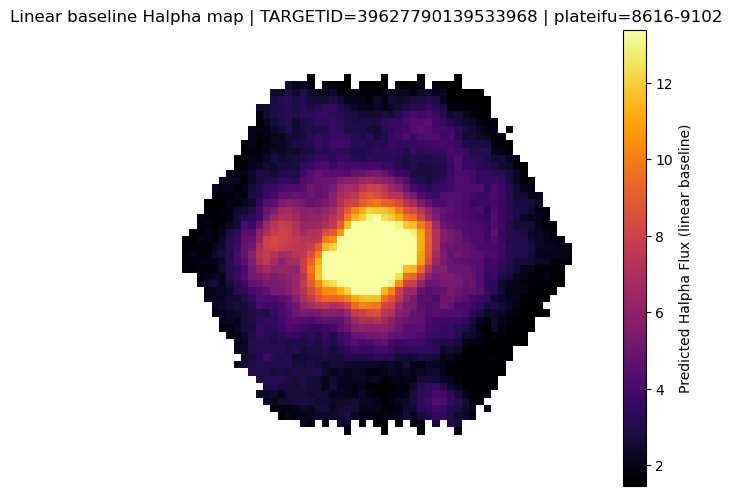

Saved linear Halpha map to: linear_halpha_map_targetid_39627790139533968.png


In [7]:
# Linear-model Halpha map for the studied object
if 'baseline_map' not in globals() or 'ctx' not in globals():
    raise RuntimeError('Run cells up to baseline map generation first.')

targetid = ctx['targetid']
plateifu = ctx['plateifu']

vals = baseline_map[np.isfinite(baseline_map)]
if vals.size > 20:
    vmin, vmax = np.percentile(vals, [5, 95])
else:
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)

plt.figure(figsize=(6, 5))
im = plt.imshow(baseline_map, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Predicted Halpha Flux (linear baseline)')
plt.title(f'Linear baseline Halpha map | TARGETID={targetid} | plateifu={plateifu}')
plt.axis('off')
plt.tight_layout()

out_png = f'linear_halpha_map_targetid_{targetid}.png'
plt.savefig(out_png, dpi=180, bbox_inches='tight')
plt.show()

print(f'Saved linear Halpha map to: {out_png}')

Normalized metrics against MaNGA truth:
                         map  n_pix  pearson_norm  cosine_norm  mae_norm  rmse_norm
halphas_simple.npy_projected   1881      0.911560     0.912314  0.364913   0.496870
             linear_baseline   1881      0.898003     0.907847  0.455236   0.772228
       halphas.npy_projected   1881      0.841477     0.837746  0.514989   0.860660
Saved metrics table to: baseline_vs_saved_maps_metrics_targetid_39627790139533968.csv


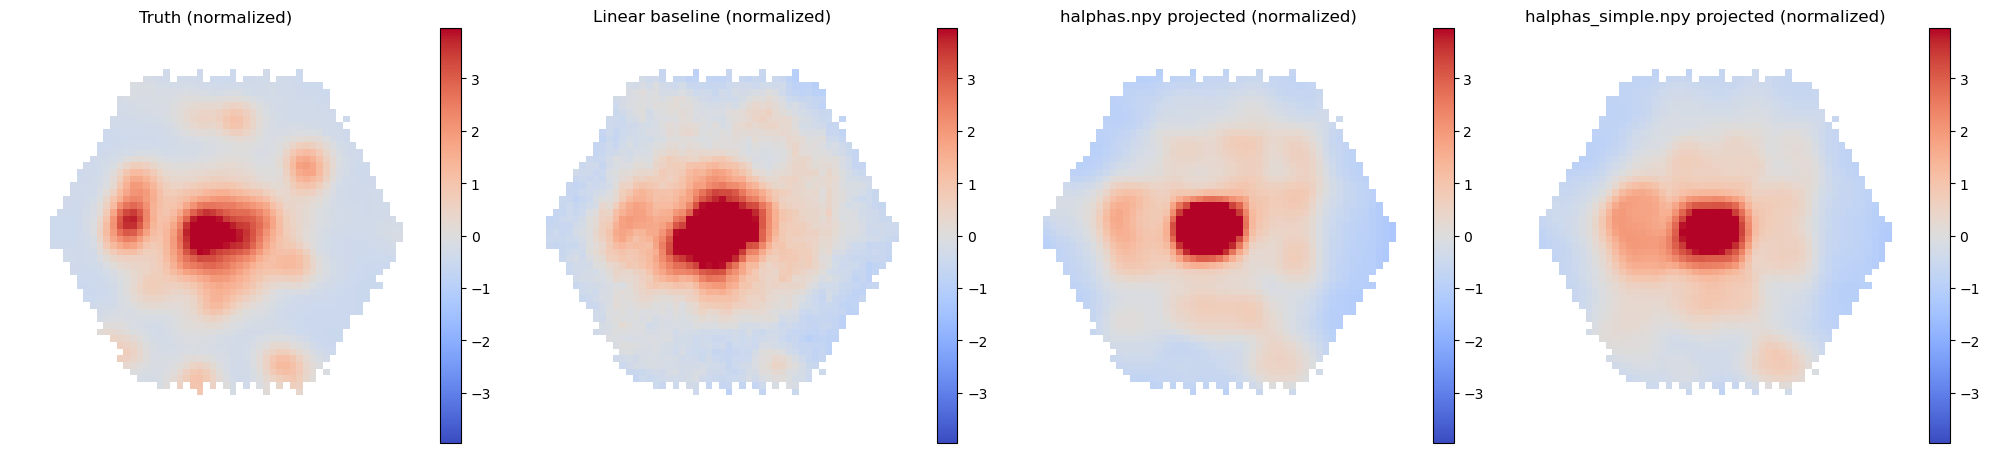

Saved normalized comparison figure to: baseline_vs_saved_maps_normalized_targetid_39627790139533968.png


In [9]:
# Compare linear baseline vs saved halphas maps against MaNGA truth (no model scan)
from scipy.interpolate import griddata

if 'ctx' not in globals() or 'baseline_map' not in globals():
    raise RuntimeError('Run cells through baseline_map generation first.')

halphas_path = '/pscratch/sd/p/pzehao/MultiModal/notebooks/halphas.npy'
halphas_simple_path = '/pscratch/sd/p/pzehao/MultiModal/notebooks/halphas_simple.npy'

if not os.path.exists(halphas_path):
    raise FileNotFoundError(halphas_path)
if not os.path.exists(halphas_simple_path):
    raise FileNotFoundError(halphas_simple_path)

halphas_disk = np.load(halphas_path)
halphas_simple_disk = np.load(halphas_simple_path)

truth = np.asarray(ctx['truth_ha'], dtype=np.float64)
x_off_map = np.asarray(ctx['x_off'], dtype=np.float64)
y_off_map = np.asarray(ctx['y_off'], dtype=np.float64)
manga_footprint = np.isfinite(truth)

def project_to_manga_grid(src_map, x_sample, y_sample, footprint):
    src = np.asarray(src_map, dtype=np.float64)
    if src.ndim != 2:
        raise ValueError(f'Expected 2D source map, got {src.shape}')

    ny_src, nx_src = src.shape
    x_src = np.linspace(-63.0, 63.0, nx_src)
    y_src = np.linspace(63.0, -63.0, ny_src)

    xx_src, yy_src = np.meshgrid(x_src, y_src)
    valid_src = np.isfinite(src)
    if int(valid_src.sum()) < 10:
        raise RuntimeError('Too few finite points in source map.')

    src_points = np.column_stack([xx_src[valid_src], yy_src[valid_src]])
    src_values = src[valid_src]
    sample_points = np.column_stack([x_sample.ravel(), y_sample.ravel()])

    proj_linear = griddata(src_points, src_values, sample_points, method='linear').reshape(x_sample.shape)
    proj_nearest = griddata(src_points, src_values, sample_points, method='nearest').reshape(x_sample.shape)

    inside_src = (
        (x_sample >= np.min(x_src)) & (x_sample <= np.max(x_src)) &
        (y_sample >= np.min(y_src)) & (y_sample <= np.max(y_src))
)

    proj = np.where(inside_src, proj_linear, np.nan)
    fill = np.isnan(proj) & inside_src
    proj[fill] = proj_nearest[fill]
    proj = np.where(footprint, proj, np.nan)
    return proj

def robust_normalize(arr):
    x = np.asarray(arr, dtype=np.float64).copy()
    m = np.isfinite(x)
    if int(m.sum()) < 10:
        return x * np.nan
    v = x[m]
    med = np.nanmedian(v)
    q25, q75 = np.nanpercentile(v, [25, 75])
    iqr = q75 - q25
    if (not np.isfinite(iqr)) or (iqr <= 0):
        s = np.nanstd(v)
        if (not np.isfinite(s)) or (s <= 0):
            s = 1.0
        x[m] = (v - med) / s
    else:
        x[m] = (v - med) / iqr
    return x

def compare_metrics(pred, truth_map):
    m = np.isfinite(pred) & np.isfinite(truth_map)
    n = int(m.sum())
    if n < 10:
        return {'n_pix': n, 'pearson_norm': np.nan, 'cosine_norm': np.nan, 'mae_norm': np.nan, 'rmse_norm': np.nan}

    pn = robust_normalize(pred[m])
    tn = robust_normalize(truth_map[m])

    pearson = float(np.corrcoef(pn, tn)[0, 1])
    denom = np.linalg.norm(pn) * np.linalg.norm(tn)
    cosine = float(np.dot(pn, tn) / denom) if denom > 0 else np.nan
    mae = float(np.mean(np.abs(pn - tn)))
    rmse = float(np.sqrt(np.mean((pn - tn) ** 2)))
    return {'n_pix': n, 'pearson_norm': pearson, 'cosine_norm': cosine, 'mae_norm': mae, 'rmse_norm': rmse}

halphas_proj = project_to_manga_grid(halphas_disk, x_off_map, y_off_map, manga_footprint)
halphas_simple_proj = project_to_manga_grid(halphas_simple_disk, x_off_map, y_off_map, manga_footprint)
baseline_proj = np.where(manga_footprint, baseline_map, np.nan)

metrics_df = pd.DataFrame([
    {'map': 'linear_baseline', **compare_metrics(baseline_proj, truth)},
    {'map': 'halphas.npy_projected', **compare_metrics(halphas_proj, truth)},
    {'map': 'halphas_simple.npy_projected', **compare_metrics(halphas_simple_proj, truth)},
]).sort_values(['pearson_norm', 'cosine_norm'], ascending=False)

print('Normalized metrics against MaNGA truth:')
print(metrics_df.to_string(index=False))

# Save metrics and figure
metrics_out = f"baseline_vs_saved_maps_metrics_targetid_{ctx['targetid']}.csv"
metrics_df.to_csv(metrics_out, index=False)
print(f'Saved metrics table to: {metrics_out}')

# Plot normalized maps for scale-independent visual comparison
truth_n = robust_normalize(truth)
baseline_n = robust_normalize(baseline_proj)
halphas_n = robust_normalize(halphas_proj)
halphas_simple_n = robust_normalize(halphas_simple_proj)

all_vals = np.concatenate([
    truth_n[np.isfinite(truth_n)],
    baseline_n[np.isfinite(baseline_n)],
    halphas_n[np.isfinite(halphas_n)],
    halphas_simple_n[np.isfinite(halphas_simple_n)],
])
v = np.nanpercentile(np.abs(all_vals), 97) if all_vals.size > 0 else 1.0
if (not np.isfinite(v)) or (v <= 0):
    v = 1.0

fig, ax = plt.subplots(1, 4, figsize=(20, 4.8))
im0 = ax[0].imshow(truth_n, origin='lower', cmap='coolwarm', vmin=-v, vmax=v)
ax[0].set_title('Truth (normalized)')
ax[0].axis('off')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(baseline_n, origin='lower', cmap='coolwarm', vmin=-v, vmax=v)
ax[1].set_title('Linear baseline (normalized)')
ax[1].axis('off')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(halphas_n, origin='lower', cmap='coolwarm', vmin=-v, vmax=v)
ax[2].set_title('halphas.npy projected (normalized)')
ax[2].axis('off')
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

im3 = ax[3].imshow(halphas_simple_n, origin='lower', cmap='coolwarm', vmin=-v, vmax=v)
ax[3].set_title('halphas_simple.npy projected (normalized)')
ax[3].axis('off')
plt.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.04)

plt.tight_layout()
out_fig = f"baseline_vs_saved_maps_normalized_targetid_{ctx['targetid']}.png"
plt.savefig(out_fig, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved normalized comparison figure to: {out_fig}')

In [5]:
# --- Model Halpha map at the exact same MaNGA spaxels ---
model = build_model_and_load(ckpt_path)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

batch = ctx['batch']
x, spec, weig, error, img, img_w, img_e, z, xy_pix = batch
spec = spec.to(device)
weig = weig.to(device)
error = error.to(device)
img = img.to(device)
img_w = img_w.to(device)
img_e = img_e.to(device)
z = z.to(device)

wave_obs = np.asarray(extractor.wave, dtype=np.float64)

model_map = np.full_like(truth_ha, np.nan, dtype=np.float64)
coords = np.column_stack([x_off[valid_eval], y_off[valid_eval]]).astype(np.float32)
yx_pairs = np.column_stack(np.where(valid_eval))

with torch.no_grad():
    n = coords.shape[0]
    for start in range(0, n, chunk_size_model):
        end = min(start + chunk_size_model, n)
        bsz = end - start

        xy_chunk = torch.as_tensor(coords[start:end], dtype=xy_pix.dtype, device=device)

        spec_b = spec.repeat(bsz, 1)
        weig_b = weig.repeat(bsz, 1)
        error_b = error.repeat(bsz, 1)
        img_b = img.repeat(bsz, 1, 1, 1)
        img_w_b = img_w.repeat(bsz, 1, 1, 1)
        img_e_b = img_e.repeat(bsz, 1, 1, 1)
        z_b = z.repeat(bsz)

        _, _, _, spec_pred, _, _, _, _ = model.forward(
            spec_b, weig_b, error_b, img_b, img_w_b, img_e_b, z_b, xy_chunk
        )

        pred_np = spec_pred.detach().cpu().numpy()
        z_np = z_b.detach().cpu().numpy()

        halpha_chunk = extract_halpha_flux_batch(
            spectra=pred_np,
            wave_obs=wave_obs,
            redshifts=z_np,
            left_patches=model.left_patches,
            patch_size=model.patch_size,
        )

        for i_local, hval in enumerate(halpha_chunk):
            y, x = yx_pairs[start + i_local]
            model_map[y, x] = hval

        print(f'Model processed {end}/{n} spaxels')

print(f'Model predicted pixels: {np.isfinite(model_map).sum()}')

/tmp/ipykernel_903248/3982059000.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chk = torch.load(path, map_location='cpu')


NameError: name 'truth_ha' is not defined

In [ ]:
def metrics(pred, truth):
    m = np.isfinite(pred) & np.isfinite(truth)
    n = int(m.sum())
    if n < 10:
        return {'n_pix': n, 'pearson': np.nan, 'mae': np.nan, 'rmse': np.nan}

    p = pred[m]
    t = truth[m]

    return {
        'n_pix': n,
        'pearson': float(np.corrcoef(p, t)[0, 1]),
        'mae': float(np.mean(np.abs(p - t))),
        'rmse': float(np.sqrt(np.mean((p - t) ** 2))),
    }

m_base = metrics(baseline_map, truth_ha)
m_model = metrics(model_map, truth_ha)

cmp = pd.DataFrame([
    {'method': 'linear_patch_to_halpha', **m_base},
    {'method': 'model_spectrum_to_halpha', **m_model},
])
print(cmp.to_string(index=False))

# Shared display range
vals = np.concatenate([
    truth_ha[np.isfinite(truth_ha)],
    baseline_map[np.isfinite(baseline_map)],
    model_map[np.isfinite(model_map)],
])
if len(vals) > 20:
    vmin, vmax = np.percentile(vals, [5, 95])
else:
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)

diff = model_map - baseline_map
d = np.nanpercentile(np.abs(diff[np.isfinite(diff)]), 95) if np.isfinite(diff).any() else 1.0
if not np.isfinite(d) or d <= 0:
    d = 1.0

fig, ax = plt.subplots(1, 4, figsize=(20, 4.8))
im0 = ax[0].imshow(truth_ha, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
ax[0].set_title('MaNGA truth Halpha')
ax[0].axis('off')
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(baseline_map, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
ax[1].set_title('Linear baseline')
ax[1].axis('off')
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(model_map, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
ax[2].set_title('Your model')
ax[2].axis('off')
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

im3 = ax[3].imshow(diff, origin='lower', cmap='RdBu_r', vmin=-d, vmax=d)
ax[3].set_title('Model - Baseline')
ax[3].axis('off')
plt.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Optional visual context
plt.figure(figsize=(5, 5))
desi_rgb = make_rgb(img_6ch[[0, 1, 3]], 'ls_grz')
plt.imshow(desi_rgb)
plt.title('DESI image context')
plt.axis('off')
plt.show()